In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/processed/ai4i2020_clean.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,soma_subtipos
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,0


In [3]:
feature_cols = ['Type', 'Air temperature [K]', 'Process temperature [K]', 
                 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

X = df[feature_cols]
y = df['Machine failure']

print(X.shape)
print(y.shape)

(9973, 6)
(9973,)


In [4]:
X_encoded = pd.get_dummies(X, columns=['Type'], drop_first=True)
X_encoded.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(7978, 7) (1995, 7)


In [6]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [7]:
y_pred = model_lr.predict(X_test)
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1929
           1       0.76      0.20      0.31        66

    accuracy                           0.97      1995
   macro avg       0.87      0.60      0.65      1995
weighted avg       0.97      0.97      0.96      1995

[[1925    4]
 [  53   13]]


In [9]:
model_lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_lr_balanced.fit(X_train, y_train)

y_pred_balanced = model_lr_balanced.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.99      0.81      0.90      1929
           1       0.14      0.88      0.24        66

    accuracy                           0.82      1995
   macro avg       0.57      0.85      0.57      1995
weighted avg       0.97      0.82      0.87      1995



In [10]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1929
           1       0.73      0.74      0.74        66

    accuracy                           0.98      1995
   macro avg       0.86      0.87      0.86      1995
weighted avg       0.98      0.98      0.98      1995



In [11]:
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

X_train_clean.columns = X_train_clean.columns.str.replace(r'[\[\]<]', '', regex=True)
X_test_clean.columns = X_test_clean.columns.str.replace(r'[\[\]<]', '', regex=True)

X_train_clean.columns

Index(['Air temperature K', 'Process temperature K', 'Rotational speed rpm',
       'Torque Nm', 'Tool wear min', 'Type_L', 'Type_M'],
      dtype='str')

In [12]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight

np.float64(29.21969696969697)

In [13]:
model_xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
model_xgb.fit(X_train_clean, y_train)

y_pred_xgb = model_xgb.predict(X_test_clean)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1929
           1       0.77      0.89      0.83        66

    accuracy                           0.99      1995
   macro avg       0.88      0.94      0.91      1995
weighted avg       0.99      0.99      0.99      1995



In [14]:
from sklearn.metrics import roc_auc_score

# Logistic Regression balanceada
y_proba_lr = model_lr_balanced.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)

# Random Forest
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)

# XGBoost
y_proba_xgb = model_xgb.predict_proba(X_test_clean)[:, 1]
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"Random Forest AUC: {auc_rf:.4f}")
print(f"XGBoost AUC: {auc_xgb:.4f}")

Logistic Regression AUC: 0.9292
Random Forest AUC: 0.9766
XGBoost AUC: 0.9774


In [15]:
import joblib

joblib.dump(model_xgb, 'models/model.pkl')

['models/model.pkl']

In [16]:
y_proba_xgb_full = model_xgb.predict_proba(X_test_clean)[:, 1]

risk_df = X_test_clean.copy()
risk_df['probabilidade_falha'] = y_proba_xgb_full
risk_df['risco'] = pd.cut(
    risk_df['probabilidade_falha'],
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=['Baixo', 'Moderado', 'Alto', 'Crítico'],
    include_lowest=True
)

risk_df['risco'].value_counts()

risco
Baixo       1908
Crítico       69
Moderado      13
Alto           5
Name: count, dtype: int64

In [17]:
import shap

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer(X_test_clean)

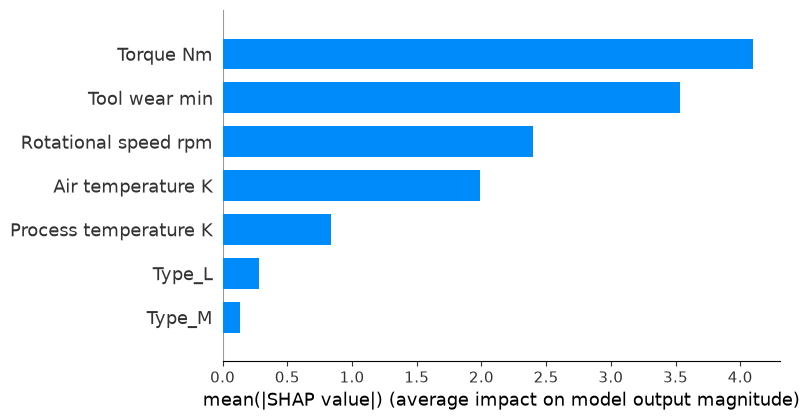

In [18]:
shap.summary_plot(shap_values, X_test_clean, plot_type="bar")

In [19]:
# pegar o índice de uma máquina com risco crítico
maquina_critica = risk_df[risk_df['risco'] == 'Crítico'].index[0]
posicao = X_test_clean.index.get_loc(maquina_critica)

print(f"Probabilidade de falha: {risk_df.loc[maquina_critica, 'probabilidade_falha']:.2%}")

Probabilidade de falha: 99.62%


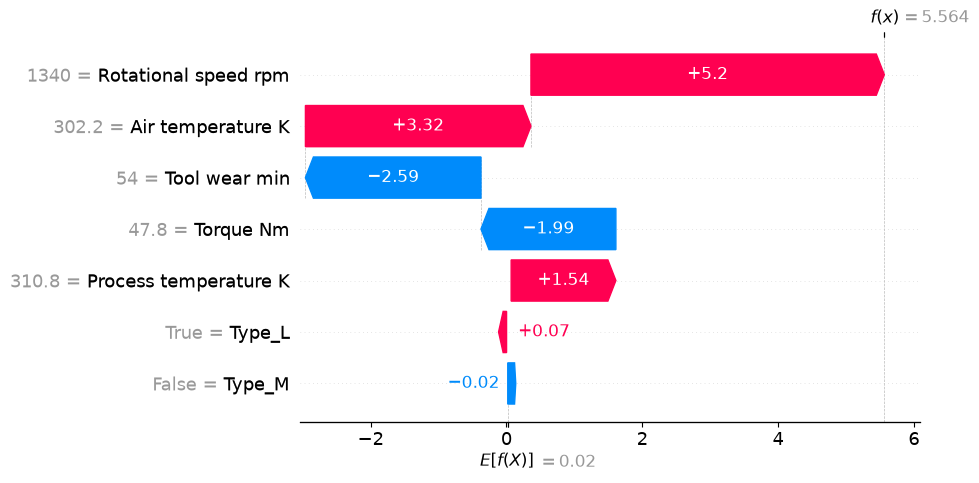

In [20]:
shap.plots.waterfall(shap_values[posicao])

In [21]:
# recriar o X completo (todas as 9973 máquinas), com o mesmo encoding
X_full_encoded = pd.get_dummies(df[feature_cols], columns=['Type'], drop_first=True)
X_full_encoded.columns = X_full_encoded.columns.str.replace(r'[\[\]<]', '', regex=True)

# gerar probabilidades para todas as máquinas
proba_full = model_xgb.predict_proba(X_full_encoded)[:, 1]

# montar o dataframe final de risco
df_risk_final = df[['UDI', 'Product ID', 'Type']].copy()
df_risk_final['probabilidade_falha'] = proba_full
df_risk_final['risco'] = pd.cut(
    df_risk_final['probabilidade_falha'],
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=['Baixo', 'Moderado', 'Alto', 'Crítico'],
    include_lowest=True
)

df_risk_final['risco'].value_counts()

risco
Baixo       9622
Crítico      333
Moderado      13
Alto           5
Name: count, dtype: int64

In [22]:
df_powerbi = df.merge(df_risk_final[['UDI', 'probabilidade_falha', 'risco']], on='UDI')
df_powerbi.to_csv('data/processed/dashboard_dataset.csv', index=False)

In [23]:
import numpy as np

importancia = pd.DataFrame({
    'feature': X_test_clean.columns,
    'importancia_media': np.abs(shap_values.values).mean(axis=0)
}).sort_values('importancia_media', ascending=False)

importancia.to_csv('data/processed/shap_importance.csv', index=False)
importancia

,feature,importancia_media
3,Torque Nm,4.102162
4,Tool wear min,3.531180
2,Rotational speed rpm,2.401639
0,Air temperature K,1.986302
1,Process temperature K,0.841230
5,Type_L,0.281598
6,Type_M,0.130403


In [24]:
# Criar blocos de 500 operações (20 blocos no total, para 9973 linhas)
df_powerbi['bloco_operacao'] = ((df_powerbi['UDI'] - 1) // 500) + 1

evolucao = df_powerbi.groupby('bloco_operacao').agg(
    total_operacoes=('Machine failure', 'count'),
    total_falhas=('Machine failure', 'sum')
).reset_index()

evolucao['taxa_falha'] = (evolucao['total_falhas'] / evolucao['total_operacoes'] * 100).round(2)

evolucao.to_csv('data/processed/evolucao_blocos.csv', index=False)
evolucao

,bloco_operacao,total_operacoes,total_falhas,taxa_falha
0,1,500,16,3.20
1,2,500,7,1.40
2,3,497,18,3.62
3,4,499,10,2.00
4,5,499,12,2.40
5,6,498,9,1.81
6,7,498,9,1.81
7,8,500,18,3.60
8,9,499,75,15.03
9,10,499,57,11.42


In [25]:
faixa_suspeita = df_powerbi[(df_powerbi['UDI'] >= 4001) & (df_powerbi['UDI'] <= 5000)]

print(faixa_suspeita['Type'].value_counts())
print(faixa_suspeita[['Torque [Nm]', 'Tool wear [min]', 'Rotational speed [rpm]']].describe())

Type
L    619
M    285
H     94
Name: count, dtype: int64
       Torque [Nm]  Tool wear [min]  Rotational speed [rpm]
count   998.000000       998.000000              998.000000
mean     39.623647       111.719439             1551.745491
std      10.697500        66.337255              201.931767
min       5.800000         0.000000             1212.000000
25%      32.400000        54.000000             1419.250000
50%      39.500000       112.500000             1511.000000
75%      47.000000       169.000000             1629.750000
max      70.600000       235.000000             2825.000000
